In [1]:
import numpy as np

import starfile
import mrcfile

import matplotlib.pyplot as plt
from cryo_ml_utils.utils import ctf as ctf_correction

In [2]:
def load_starfile(path):
    file = starfile.read(path)
    optics = file["optics"]
    particles = file["particles"]

    img_path = particles["rlnImageName"][0]
    defocus_u = particles["rlnDefocusU"][0]
    defocus_v = particles["rlnDefocusV"][0]
    defocus_angle = particles["rlnDefocusAngle"][0]
    voltage = optics["rlnVoltage"][0]
    spherical_aberration = optics["rlnSphericalAberration"][0]
    amplitude_contrast_ratio = optics["rlnAmplitudeContrast"][0]
    phase_shift = particles["rlnPhaseShift"][0]
    bfactor = particles["rlnCtfBfactor"][0]

    pixel_size = optics["rlnImagePixelSize"][0]

    img_idx, img_path = img_path.split("@")
    img_idx = int(img_idx)

    return (img_idx, img_path), (
        pixel_size,
        defocus_u,
        defocus_v,
        defocus_angle,
        voltage,
        spherical_aberration,
        amplitude_contrast_ratio,
        phase_shift,
        bfactor,
    )

In [3]:
def plot_power_spectrum(img, ax=plt):
    img_fft = np.fft.fft2(img)
    img_fft = np.fft.fftshift(img_fft)

    power_spectrum = np.abs(img_fft) ** 2
    log_power = np.log1p(power_spectrum)

    ax.imshow(log_power, cmap="gray")

In [4]:
from skimage.restoration import wiener
import scipy

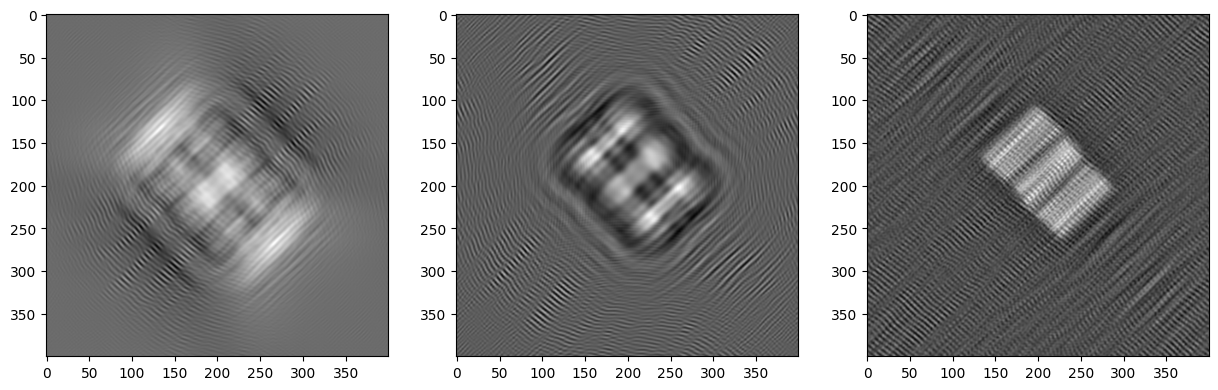

In [24]:
fig, (ax_1, ax_2, ax_3) = plt.subplots(1, 3)
fig.set_figwidth(15)

(img_idx, img_path), ctf_data = load_starfile("/home/mzoch/data/cryo-dino/cryoSolver/dino/data/emd_53910_projected.star")
(ref_img_idx, ref_img_path), _ = load_starfile("/home/mzoch/data/cryo-dino/cryoSolver/dino/data/emd_53910_projected_no_ctf.star")

(
    pixel_size,
    defocus_u,
    defocus_v,
    defocus_angle,
    voltage,
    spherical_aberration,
    amplitude_contrast_ratio,
    phase_shift,
    bfactor,
) = ctf_data

freqs = ctf_correction._get_2d_frequencies(400, pixel_size)
ctf = ctf_correction._compute_ctf(
    freqs,
    dfu=defocus_u,
    dfv=defocus_v,
    dfang=defocus_angle,
    volt=voltage,
    cs=spherical_aberration,
    w=amplitude_contrast_ratio,
    phase_shift=phase_shift,
    bfactor=bfactor,
)

ctf = np.reshape(ctf, [400, 400])

with mrcfile.mmap(img_path, permissive=True) as file, mrcfile.mmap(ref_img_path, permissive=True) as ref_file:
    # img = np.array(ds_test[10][0][0])
    img = np.array(file.data[img_idx])
    ref_img = np.array(ref_file.data[ref_img_idx])

    fft_img = np.fft.fft2(ref_img)
    conv_img = np.fft.ifft2(fft_img.real * ctf)
    

    corrected_img = ctf_correction.correct_ctf(
        img,
        *ctf_data,
        mode="wiener",
        wiener_parameter=0.1
    )

    # # plot_power_spectrum(img, ax=ax_1)
    ax_1.imshow(conv_img.real, cmap="gray")
    ax_2.imshow(img, cmap="gray")
    ax_3.imshow(corrected_img, cmap="gray")

    # # plot_power_spectrum(corrected_img, ax=ax_2)
    # # plot_power_spectrum(ref_img, ax=ax_3)

    # ax_1.set_title("Particle with CTF")
    # ax_2.set_title("Corrected CTF")
    # ax_3.set_title("Reference")

In [ ]:
class CTF:
    def __init__(self, voltage=300.0, cs=2.7, ampcontrast=7.0, defocus=0.5, dfdiff=0.0, dfang=0.0, phaseshift=0.0, bfactor=0.0, alpha=0.0, cc=2.7, dE=0.0, dI=0.0, dZ=0.0, dXY=0.0, apix=1.0, imagesize=256, over_sample=1, ctf_type='CTF', show_marker=0, ctf_intact_first_peak=0, apix_wrong=0.0, defocus_wrong=None):
        self.voltage = voltage
        self.cs = cs
        self.ampcontrast = ampcontrast
        self.defocus = defocus
        self.defocus_wrong = defocus_wrong if defocus_wrong is not None else defocus
        self.dfdiff = dfdiff
        self.dfang = dfang
        self.phaseshift = phaseshift
        self.bfactor = bfactor
        self.alpha = alpha
        self.cc = cc
        self.dE = dE
        self.dI = dI
        self.dZ = dZ
        self.dXY = dXY
        self.apix = apix
        self.apix_wrong = apix_wrong if apix_wrong>0 else apix
        self.imagesize = int(imagesize)
        self.over_sample = int(over_sample)
        self.ctf_type = ctf_type    # CTF, |CTF|, CTF^2
        self.show_marker = int(show_marker)
        self.ctf_intact_first_peak = int(ctf_intact_first_peak)

    
    def __str__(self):
        return str(self.get_dict())

    def __repr__(self):
        return self.__str__()

    def copy(self):
        import copy
        return copy.copy(self)
    
    def get_dict(self):
        ret = {}
        for attr in sorted(self.__dict__):
            ret[attr] = self.__dict__[attr]
        return ret

    def wave_length(self):
        wl = 12.2639 / np.sqrt(self.voltage * 1000.0 + 0.97845 * self.voltage * self.voltage)  # Angstrom
        return wl

    #@st.cache_data(persist=True, show_spinner=False)
    def ctf2d(self, plot_s2=False, env_only=False):    
        s_nyquist = 1./(2*self.apix)
        if plot_s2:
            ds = None
            ds2 = s_nyquist*s_nyquist/(self.imagesize//2*self.over_sample)
            sx2 = np.arange(-self.imagesize*self.over_sample//2, self.imagesize*self.over_sample//2) * ds2
            sy2 = np.arange(-self.imagesize*self.over_sample//2, self.imagesize*self.over_sample//2) * ds2
            sx2, sy2 = np.meshgrid(sx2, sy2, indexing='ij')
            theta = -np.arctan2(sy2, sx2)
            s2 = np.hypot(sx2, sy2)
            s = np.sqrt(s2)
            del sx2, sy2
        else:
            ds2 = None
            ds = s_nyquist/(self.imagesize//2*self.over_sample)
            sx = np.arange(-self.imagesize*self.over_sample//2, self.imagesize*self.over_sample//2) * ds
            sy = np.arange(-self.imagesize*self.over_sample//2, self.imagesize*self.over_sample//2) * ds
            sx, sy = np.meshgrid(sx, sy, indexing='ij')
            theta = -np.arctan2(sy, sx)
            s2 = sx*sx + sy*sy
            s = np.sqrt(s2)
            del sx, sy

        defocus2d = self.defocus + self.dfdiff/2*np.cos( 2*(theta-self.dfang*np.pi/180.))

        wl = self.wave_length()  # Angstrom
        phaseshift = self.phaseshift * np.pi / 180.0 + np.arcsin(self.ampcontrast/100.)

        gamma =2*np.pi*(-0.5*defocus2d*1e4*wl*s2 + .25*self.cs*1e7*wl**3*s2**2) - phaseshift

        from scipy.special import j0, sinc
        env = np.ones_like(gamma)
        if self.bfactor: env *= np.exp(-self.bfactor*s2/4.0)
        if self.alpha: env *= np.exp(-np.power(np.pi*self.alpha*(1.0e7*self.cs*wl*wl*s*s*s-1e4*self.defocus*s), 2.0)*1e-6)
        if self.dE: env *= np.exp(-np.power(np.pi*self.cc*wl*s*s* self.dE/self.voltage, 2.0)/(16*np.log(2))*1e8)
        if self.dI: env *= np.exp(-np.power(np.pi*self.cc*wl*s*s* self.dI,              2.0)/(4*np.log(2))*1e2)
        if self.dZ: env *= j0(np.pi*self.dZ*wl*s*s)
        if self.dXY: env *= sinc(np.pi*self.dXY*s)

        if env_only:
            return ds, ds2, env

        ctf = np.sin(gamma) * env
        if self.ctf_type == "CTF^2": ctf = ctf*ctf
        elif self.ctf_type== "|CTF|": ctf = np.abs(ctf)
        del gamma, env, phaseshift, defocus2d, s, s2, theta
        return ds, ds2, ctf

In [26]:
defocus_u, defocus_v

(np.float64(34831.073502), np.float64(34454.94948))

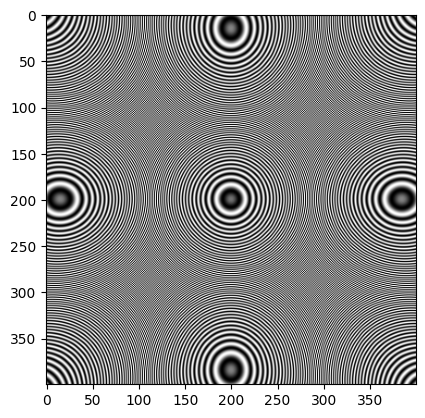

In [29]:
(
    pixel_size,
    defocus_u,
    defocus_v,
    defocus_angle,
    voltage,
    spherical_aberration,
    amplitude_contrast_ratio,
    phase_shift,
    bfactor,
) = ctf_data

freqs = ctf_correction._get_2d_frequencies(400, pixel_size)
ctf = ctf_correction._compute_ctf(
    freqs,
    dfu=34000,
    dfv=34000,
    dfang=defocus_angle,
    volt=voltage,
    cs=spherical_aberration,
    w=amplitude_contrast_ratio,
    phase_shift=phase_shift,
    bfactor=bfactor,
)

ctf = np.reshape(ctf, [400, 400])
plt.imshow(-ctf, cmap="gray")

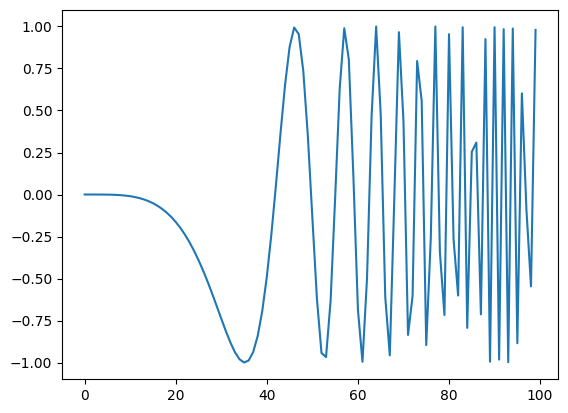

In [ ]:
Z = 1
lam = 1
C_s = 2.7
C_s = C_s * 10**7

volt = 300

def C(s, ang):
    wavelength = 12.2639 / np.sqrt(volt * 1000.0 + 0.97845 * volt ** 2)
    df = 0.5 * np.cos(2 * (ang - dfang)) # (dfu + dfv + (dfu - dfv) *

    return np.sin(2 * np.pi * (0.5 * (wavelength ** 2 * s**2)) - 0.25 * (s**4*wavelength**4) * C_s)

x = np.linspace(0, np.pi, 100)
plt.plot(C(x, 0.0))